# Data Cleaning and Data Visualization

A practical walkthrough using the included employee dataset. The raw data intentionally contains missing values, inconsistent text, a duplicate record and an implausible age. Examples show both code and outputs; review each result before deciding how to clean data.

**Sections:** inspect data, clean text and types, missing values, duplicates, validation, outliers, feature creation, Matplotlib/Seaborn charts, correlation, pair plots, subplots and export.

## 1. Import libraries and load data

Run this notebook from its folder so the relative CSV path resolves.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd()
if not (BASE_DIR / "employee_raw_data.csv").exists():
    BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else BASE_DIR

df_raw = pd.read_csv(BASE_DIR / "employee_raw_data.csv")
df = df_raw.copy()
display(df.head())
print("Shape:", df.shape)

,Employee ID,Employee Name,Department,Age,Experience,Salary,Join Date,Performance Rating,Email
0,101,Aisha Khan,IT,25.0,2,45000.0,2022-01-10,4,aisha@example.com
1,102,Rahul Sharma,hr,NaN,4,52000.0,2021/03/15,3,rahul@example.com
2,103,neha verma,Finance,29.0,5,61000.0,2020-07-01,4,neha@example.com
3,104,Imran Ali,IT,34.0,10,85000.0,2018-11-21,5,imran@example.com
4,105,Priya Singh,Sales,27.0,3,48000.0,2023-02-01,3,priya@example.com


Shape: (20, 9)


## 2. Inspect data quality

`head()` previews the first five rows, `info()` reports data types and non-null counts, and `describe()` summarizes numeric columns.

In [2]:
display(df.head())
display(df.tail(3))
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

,Employee ID,Employee Name,Department,Age,Experience,Salary,Join Date,Performance Rating,Email
0,101,Aisha Khan,IT,25.0,2,45000.0,2022-01-10,4,aisha@example.com
1,102,Rahul Sharma,hr,NaN,4,52000.0,2021/03/15,3,rahul@example.com
2,103,neha verma,Finance,29.0,5,61000.0,2020-07-01,4,neha@example.com
3,104,Imran Ali,IT,34.0,10,85000.0,2018-11-21,5,imran@example.com
4,105,Priya Singh,Sales,27.0,3,48000.0,2023-02-01,3,priya@example.com


,Employee ID,Employee Name,Department,Age,Experience,Salary,Join Date,Performance Rating,Email
17,118,Anaya Roy,Sales,28.0,3,49000.0,2023-04-16,4,anaya@example.com
18,119,Omar Siddiqui,HR,35.0,12,87000.0,2016-10-10,4,omar@example.com
19,120,Tara Nair,Marketing,32.0,7,76000.0,2020-08-08,3,tara@example.com


Shape: (20, 9)

Data types:
Employee ID             int64
 Employee Name         object
Department             object
Age                   float64
Experience              int64
Salary                float64
Join Date              object
Performance Rating      int64
Email                  object
dtype: object

Missing values:
Employee ID           0
 Employee Name        0
Department            0
Age                   2
Experience            0
Salary                1
Join Date             0
Performance Rating    0
Email                 0
dtype: int64

Duplicate rows: 1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee ID,20.0,NaN,NaN,NaN,110.45,5.871205,101.0,105.75,110.5,115.0,120.0
Employee Name,20,19,Nida Khan,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,20,7,IT,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,18.0,NaN,NaN,NaN,38.277778,28.358639,24.0,28.0,31.5,36.5,150.0
Experience,20.0,NaN,NaN,NaN,7.15,4.463595,1.0,3.75,6.5,10.25,16.0
Salary,19.0,NaN,NaN,NaN,72157.894737,25146.820338,42000.0,49500.0,65000.0,89500.0,120000.0
Join Date,20,19,2014-07-11,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance Rating,20.0,NaN,NaN,NaN,3.85,0.875094,2.0,3.0,4.0,4.25,5.0
Email,20,19,nida@example.com,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Standardize column names and text

Use predictable snake_case names and consistent text formatting.

In [3]:
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(r"[^a-z0-9]+", "_", regex=True)
              .str.strip("_"))
df["employee_name"] = df["employee_name"].astype("string").str.strip().str.title()
df["department"] = df["department"].astype("string").str.strip().str.title()
df["email"] = df["email"].astype("string").str.strip().str.lower()
print(df[["employee_name", "department", "email"]].head())

  employee_name department              email
0    Aisha Khan         It  aisha@example.com
1  Rahul Sharma         Hr  rahul@example.com
2    Neha Verma    Finance   neha@example.com
3     Imran Ali         It  imran@example.com
4   Priya Singh      Sales  priya@example.com


## 4. Convert data types and remove exact duplicates

In [4]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df["experience"] = pd.to_numeric(df["experience"], errors="coerce")
df["join_date"] = pd.to_datetime(df["join_date"], errors="coerce")
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().copy()
print("Duplicates after:", df.duplicated().sum())
print(df.dtypes)

Duplicates before: 1
Duplicates after: 0
employee_id                    int64
employee_name         string[python]
department            string[python]
age                          float64
experience                     int64
salary                       float64
join_date             datetime64[ns]
performance_rating             int64
email                 string[python]
dtype: object


## 5. Validate ranges and handle missing values

Here, age outside 18–65 is flagged as suspicious for this example. This is a teaching rule, not a universal definition of valid age.

In [5]:
invalid_age = ~df["age"].between(18, 65) & df["age"].notna()
display(df.loc[invalid_age, ["employee_name", "age"]])
df.loc[invalid_age, "age"] = np.nan
print("Missing before imputation:\n", df.isna().sum())
for column in ["age", "salary"]:
    df[column] = df[column].fillna(df[column].median())
print("Missing after numeric imputation:\n", df.isna().sum())

,employee_name,age
16,Vikram Shah,150.0


Missing before imputation:
 employee_id           0
employee_name         0
department            0
age                   3
experience            0
salary                1
join_date             1
performance_rating    0
email                 0
dtype: int64
Missing after numeric imputation:
 employee_id           0
employee_name         0
department            0
age                   0
experience            0
salary                0
join_date             1
performance_rating    0
email                 0
dtype: int64


### Other missing-value strategies

Choose based on the reason for missingness. These alternatives are examples; don't run all of them blindly.

In [6]:
# Drop rows only when missing values make them unusable:
# df.dropna(subset=["salary"])

# Fill a categorical field with an explicit label:
# df["department"] = df["department"].fillna("Unknown")

# Fill with the most common category when appropriate:
# mode = df["department"].mode(dropna=True)
# if not mode.empty:
#     df["department"] = df["department"].fillna(mode.iloc[0])

# Check missing-value percentage:
print((df.isna().mean() * 100).round(1))

employee_id           0.0
employee_name         0.0
department            0.0
age                   0.0
experience            0.0
salary                0.0
join_date             5.3
performance_rating    0.0
email                 0.0
dtype: float64


## 6. Text validation with regular expressions

This basic email pattern checks format only; it cannot prove that an address exists.

In [7]:
df["email_valid"] = df["email"].str.match(r"^[\w.+-]+@[\w-]+\.[\w.-]+$", na=False)
print(df["email_valid"].value_counts(dropna=False))
# Example cleanup for a text column containing repeated spaces:
# df["notes"] = df["notes"].str.replace(r"\s+", " ", regex=True).str.strip()

email_valid
True    19
Name: count, dtype: Int64


## 7. Detect potential outliers with IQR

Outliers are values to investigate, not automatically errors.

In [8]:
q1 = df["salary"].quantile(0.25)
q3 = df["salary"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[df["salary"].lt(lower) | df["salary"].gt(upper)]
print("IQR bounds:", lower, upper)
display(outliers[["employee_name", "salary"]])
# Optional capping, only if justified for your analysis:
# df["salary_capped"] = df["salary"].clip(lower=lower, upper=upper)

IQR bounds: -5250.0 140750.0


,employee_name,salary


## 8. Create useful features and encode categories

In [9]:
df["join_year"] = df["join_date"].dt.year
df["experience_band"] = pd.cut(
    df["experience"], bins=[-1, 2, 5, 10, np.inf],
    labels=["0-2", "3-5", "6-10", "10+"]
)
display(df[["employee_name", "join_year", "experience", "experience_band"]].head())
# One-hot encoding example:
# encoded = pd.get_dummies(df, columns=["department"], dtype=int)

,employee_name,join_year,experience,experience_band
0,Aisha Khan,2022.0,2,0-2
1,Rahul Sharma,NaN,4,3-5
2,Neha Verma,2020.0,5,3-5
3,Imran Ali,2018.0,10,6-10
4,Priya Singh,2023.0,3,3-5


## 9. Histogram and KDE: salary distribution

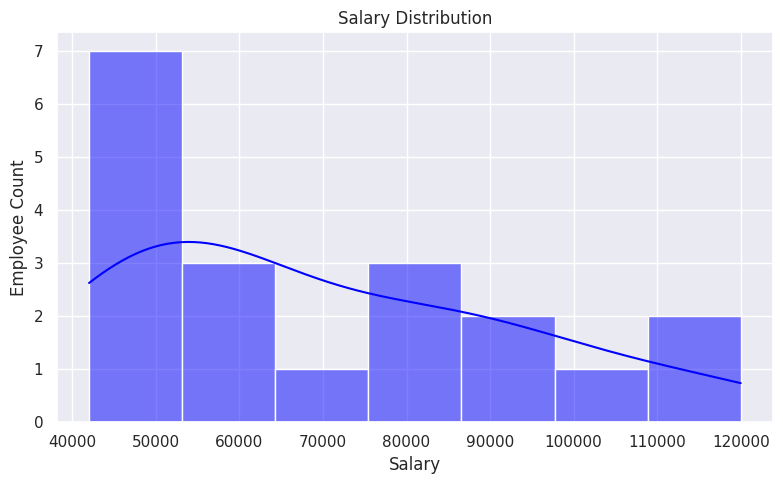

In [10]:
sns.set_theme(palette='deep')
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["salary"], bins=7, kde=True, color="blue", ax=ax)
ax.set(title="Salary Distribution", xlabel="Salary", ylabel="Employee Count")
fig.tight_layout()
plt.show()

## 10. Bar chart and count plot: categories

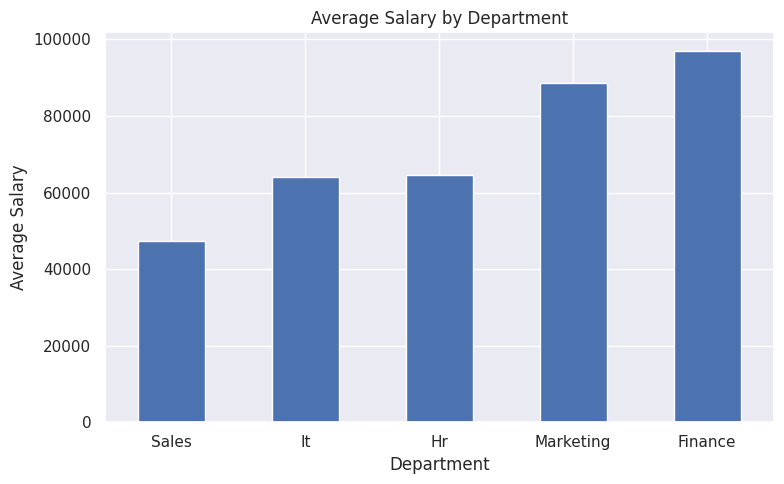

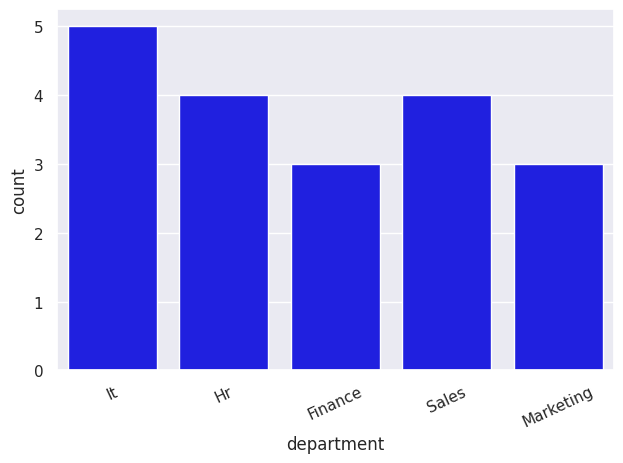

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("department", observed=True)["salary"].mean().sort_values().plot(kind="bar", ax=ax)
ax.set(title="Average Salary by Department", xlabel="Department", ylabel="Average Salary")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

sns.countplot(data=df, x="department", color="blue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 11. Scatter plot: experience versus salary

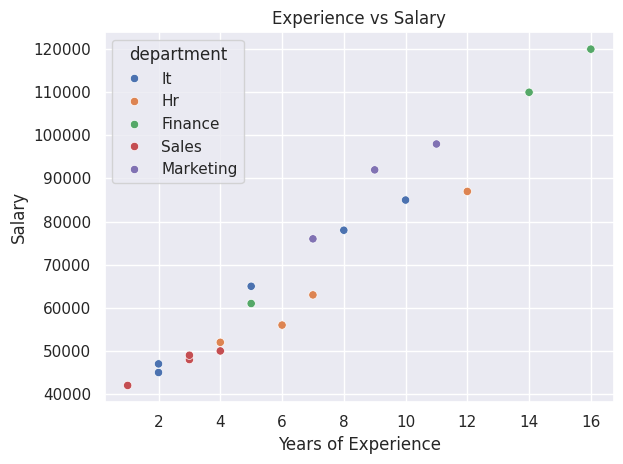

In [12]:
sns.scatterplot(data=df, x="experience", y="salary", hue="department")
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

## 12. Box plot and violin plot

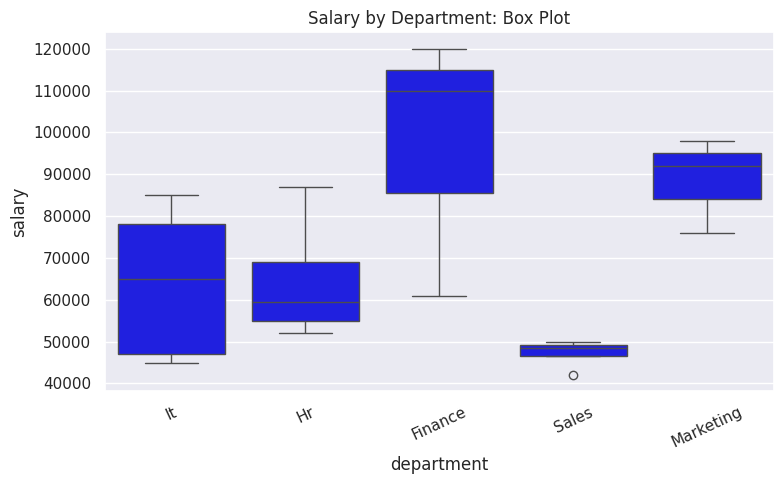

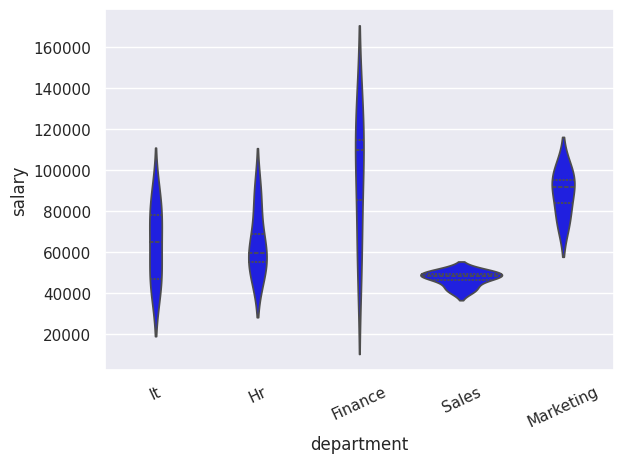

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="department", y="salary", color="blue", ax=ax)
ax.set_title("Salary by Department: Box Plot")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

sns.violinplot(data=df, x="department", y="salary", inner="quartile", color="blue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 13. Correlation heatmap

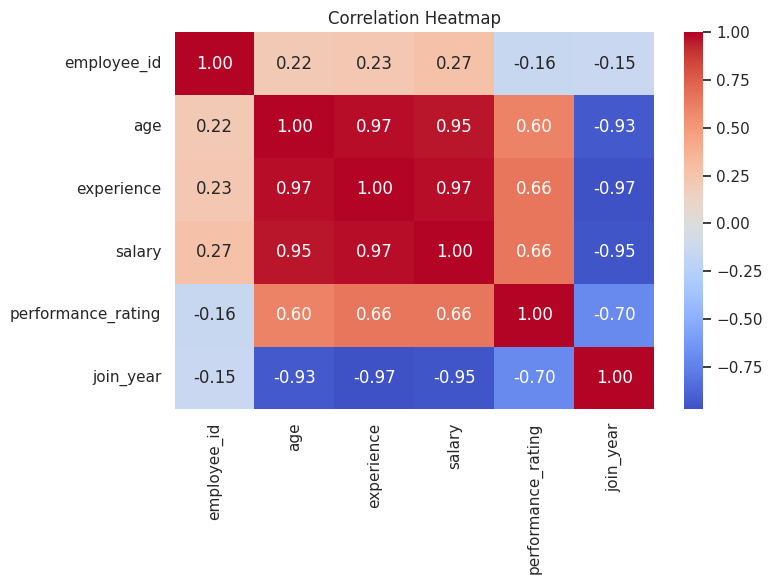

In [14]:
numeric = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", center=0, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap")
fig.tight_layout()
plt.show()

## 14. Pair plot

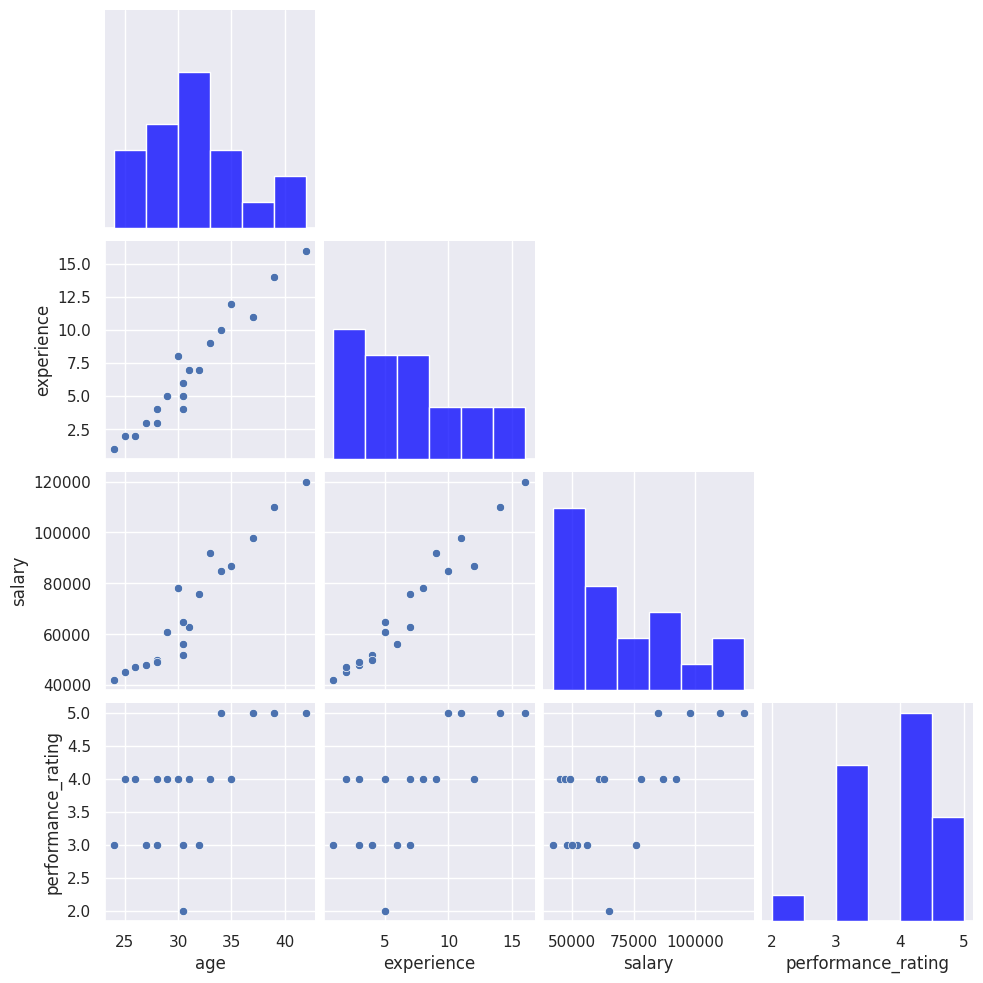

In [15]:
pair_grid = sns.pairplot(df[["age", "experience", "salary", "performance_rating"]], corner=True, diag_kws={"color": "blue"})
plt.show()

## 15. Subplots, annotation and saving figures

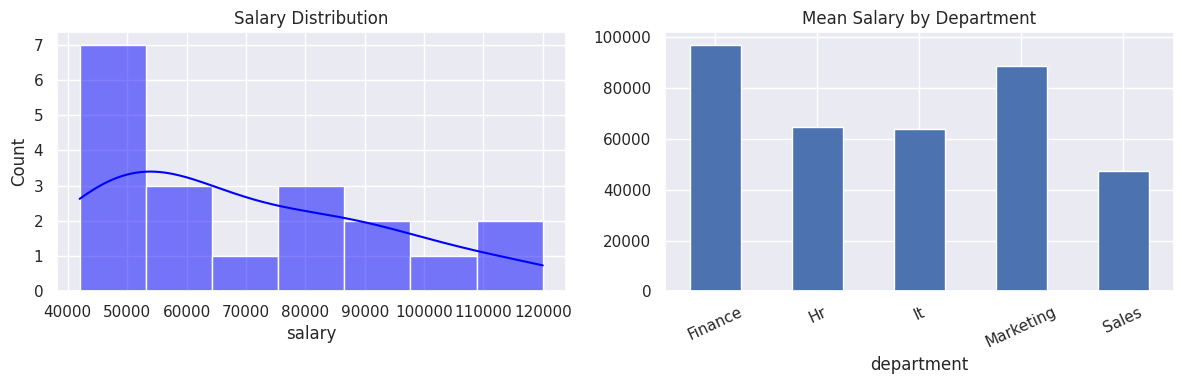

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["salary"], bins=7, kde=True, color="blue", ax=axes[0])
axes[0].set_title("Salary Distribution")
df.groupby("department", observed=True)["salary"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Mean Salary by Department")
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(BASE_DIR / "images" / "combined_subplots.png", dpi=150, bbox_inches="tight")
plt.show()

# General Matplotlib annotation example:
# ax.annotate("Important point", xy=(x_value, y_value), xytext=(x2, y2),
#             arrowprops={"arrowstyle": "->"})

## 16. Review results and export cleaned data

In [17]:
print("Final shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
df.to_csv(BASE_DIR / "employee_cleaned_data.csv", index=False)
print("Saved:", BASE_DIR / "employee_cleaned_data.csv")

Final shape: (19, 12)
Missing values:
 employee_id           0
employee_name         0
department            0
age                   0
experience            0
salary                0
join_date             1
performance_rating    0
email                 0
email_valid           0
join_year             1
experience_band       0
dtype: int64
Duplicate rows: 0
Saved: /mnt/data/Data_Cleaning_and_Visualization/employee_cleaned_data.csv


## Key reminders

- Keep raw data unchanged and save cleaned data separately.
- Missing-value strategies depend on context; imputation changes data.
- Investigate outliers before changing them.
- Use chart types that match the question and label axes clearly.
- Correlation and visual association do not prove causation.
- For machine learning, fit preprocessing steps on training data only to avoid data leakage.